# Customer Churn Modeling

This notebook tunes and compares three supervised learning models on the provided customer churn training and testing splits:

- Logistic Regression as an interpretable baseline
- Random Forest as a robust non-linear benchmark
- Histogram-based Gradient Boosting as a higher-capacity boosted-tree model

The workflow uses grid search inside the training data, selects a threshold on validation data, refits the best model on the full training split, and evaluates final performance on the untouched test split.

In [1]:
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from customer_churn_analysis.data import load_clean_train_test
from customer_churn_analysis.modeling import (
    FEATURE_COLUMNS,
    build_comparison_table,
    extract_model_signal_table,
    plot_calibration_curves,
    plot_confusion_count_matrices,
    plot_confusion_matrices,
    plot_model_metric_comparison,
    plot_pca_component_projection,
    plot_roc_and_precision_recall,
    plot_train_vs_test_metrics,
    predict_single_customer,
    train_and_compare_models,
    write_model_evaluation_report,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
datasets = load_clean_train_test()
train_df = datasets["train"]
test_df = datasets["test"]

pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "churn_rate": [train_df["churn"].dropna().mean(), test_df["churn"].dropna().mean()],
    }
).round(3)

,split,rows,churn_rate
0,train,440832,0.567
1,test,64374,0.474


## Tune And Compare Models

In [3]:
evaluations = train_and_compare_models()

Training 2 model(s) with GridSearchCV using 7 CPU core(s).

Training model: logistic_regression
Fitting 4 folds for each of 5 candidates, totalling 20 fits

Training model: random_forest
Fitting 4 folds for each of 1 candidates, totalling 4 fits


In [4]:
[evaluation.best_params for evaluation in evaluations]

[{'classifier__C': 0.8, 'classifier__class_weight': None},
 {'classifier__max_depth': 10,
  'classifier__max_features': None,
  'classifier__min_samples_leaf': 50,
  'classifier__min_samples_split': 2,
  'classifier__n_estimators': 100}]

In [5]:
summary_df = pd.DataFrame(
    [
        {
            "model_name": evaluation.model_name,
            "selected_threshold": evaluation.threshold,
            "cv_roc_auc": evaluation.cross_validation_score,
            "best_params": str(evaluation.best_params),
        }
        for evaluation in evaluations
    ]
).round(3)

display(summary_df, truncate=False)

,model_name,selected_threshold,cv_roc_auc,best_params
0,logistic_regression,0.90,0.96,"{'classifier__C': 0.8, 'classifier__class_weig..."
1,random_forest,0.65,1.00,"{'classifier__max_depth': 10, 'classifier__max..."


In [6]:
comparison_table = build_comparison_table(evaluations)
comparison_table

,model_name,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision,brier_score
0,logistic_regression,0.636,0.651,0.57,0.937,0.365,0.709,0.696,0.649,0.387
1,random_forest,0.506,0.531,0.49,0.998,0.063,0.657,0.532,0.490,0.494


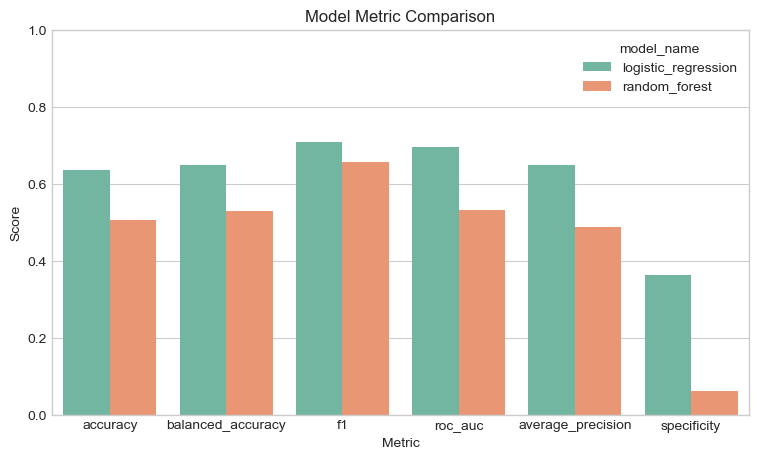

In [7]:
plot_model_metric_comparison(comparison_table)
plt.show()

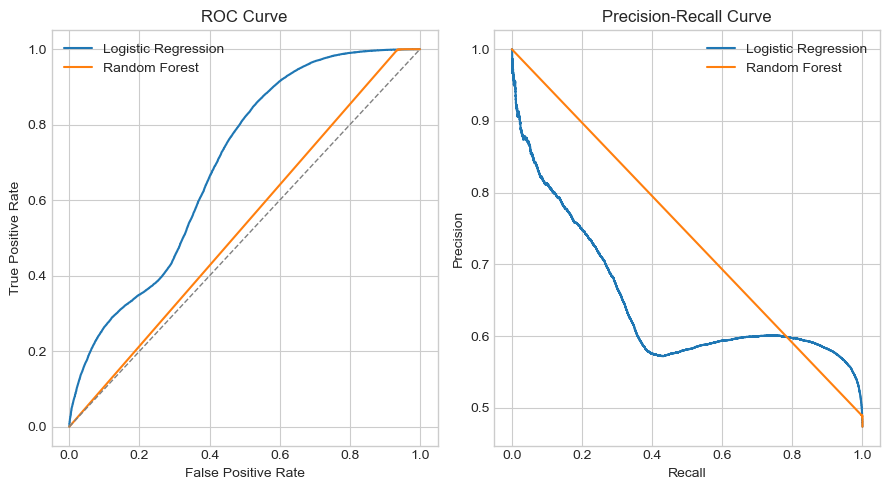

In [8]:
plot_roc_and_precision_recall(evaluations)
plt.show()

## PCA View

Only the logistic-regression pipeline uses PCA, so the projection below helps show how much of the processed feature variation is captured by the first two components.

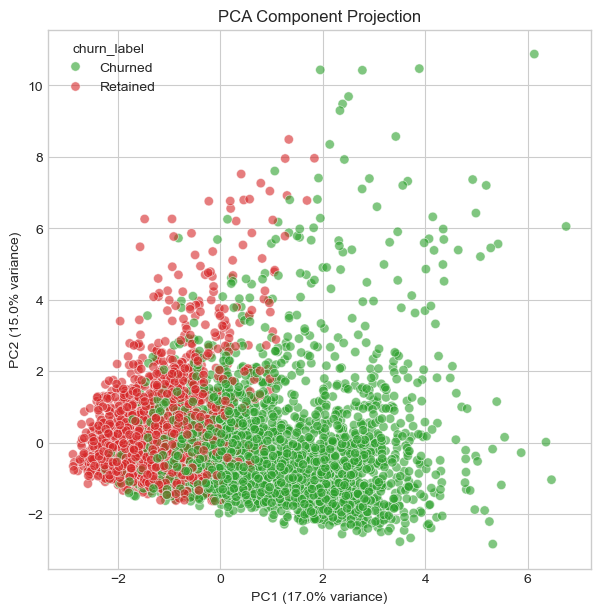

In [9]:
logistic_evaluation = next(
    evaluation for evaluation in evaluations
    if evaluation.model_name == "logistic_regression"
)

plot_pca_component_projection(
    logistic_evaluation,
    train_df[FEATURE_COLUMNS],
    train_df["churn"].astype(int),
)
plt.show()

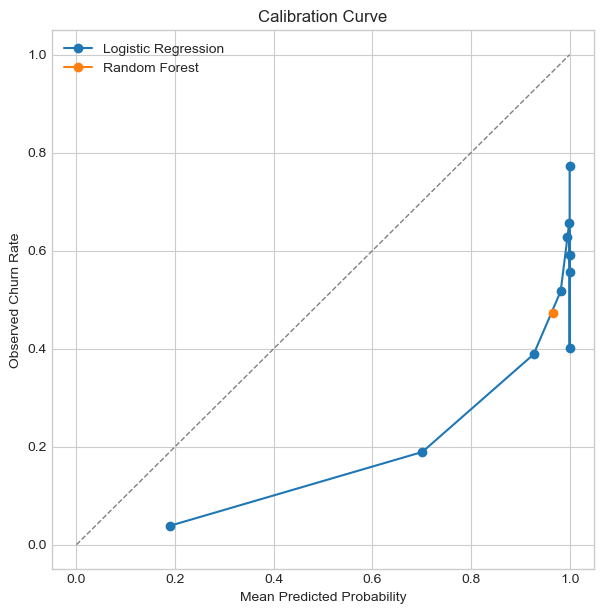

In [10]:
plot_calibration_curves(evaluations)
plt.show()

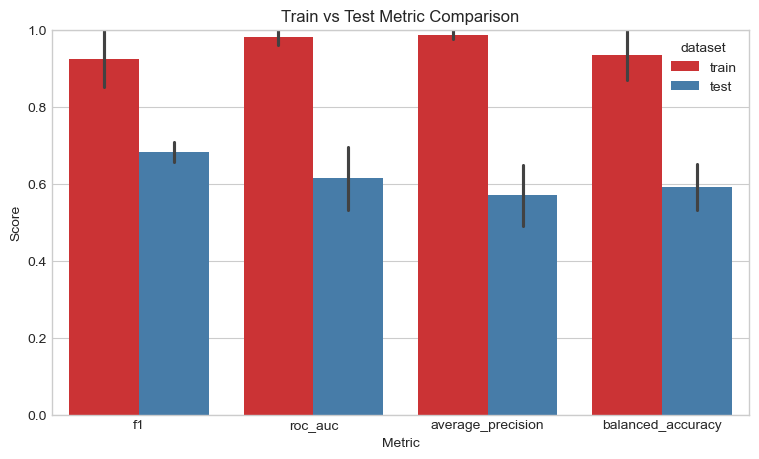

In [11]:
plot_train_vs_test_metrics(evaluations)
plt.show()

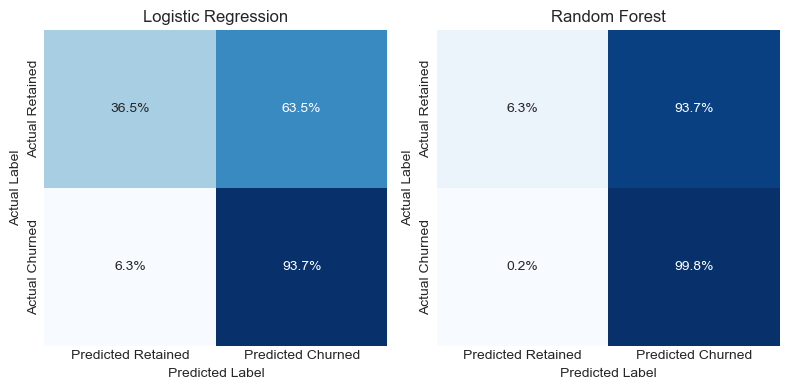

In [12]:
plot_confusion_matrices(evaluations)
plt.show()

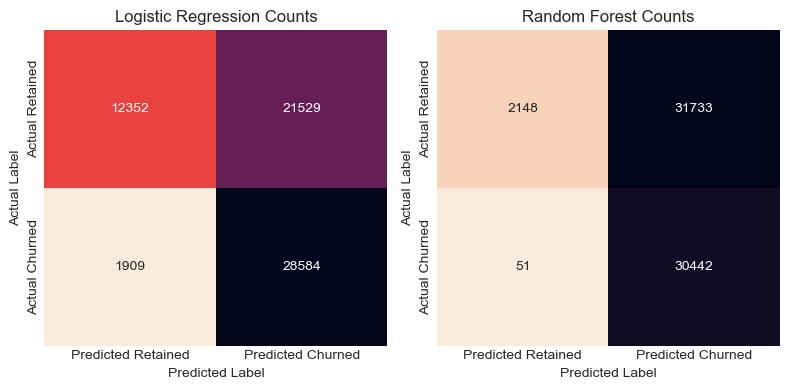

In [13]:
plot_confusion_count_matrices(evaluations)
plt.show()

## Reports and Model Signals

In [14]:
for evaluation in evaluations:
    title = evaluation.model_name.replace("_", " ").title()
    display(Markdown(f"### {title}"))
    print(evaluation.classification_report_text)

### Logistic Regression

              precision    recall  f1-score   support

           0      0.866     0.365     0.513     33881
           1      0.570     0.937     0.709     30493

    accuracy                          0.636     64374
   macro avg      0.718     0.651     0.611     64374
weighted avg      0.726     0.636     0.606     64374



### Random Forest

              precision    recall  f1-score   support

           0      0.977     0.063     0.119     33881
           1      0.490     0.998     0.657     30493

    accuracy                          0.506     64374
   macro avg      0.733     0.531     0.388     64374
weighted avg      0.746     0.506     0.374     64374



In [15]:
train_signal_df = train_df.dropna(subset=["churn"]).copy()

for evaluation in evaluations:
    title = evaluation.model_name.replace("_", " ").title()
    display(Markdown(f"### {title} Signals"))
    display(
        extract_model_signal_table(
            evaluation,
            train_signal_df[FEATURE_COLUMNS],
            train_signal_df["churn"].astype(int),
        )
    )

### Logistic Regression Signals

,feature,importance,absolute_importance
0,pc_1,3.889,3.889
8,pc_9,-1.917,1.917
4,pc_5,1.132,1.132
13,pc_14,-1.118,1.118
1,pc_2,-0.911,0.911
2,pc_3,-0.730,0.730
14,pc_15,0.652,0.652
6,pc_7,-0.609,0.609
9,pc_10,0.546,0.546
7,pc_8,0.448,0.448


### Random Forest Signals

,feature,importance,absolute_importance
4,support_calls,2.169796e-01,2.169796e-01
8,total_spend,1.460944e-01,1.460944e-01
0,age,1.419802e-01,1.419802e-01
7,contract_length,1.087684e-01,1.087684e-01
5,payment_delay_days,1.027139e-01,1.027139e-01
9,last_interaction_days,7.606044e-02,7.606044e-02
1,gender,7.427879e-02,7.427879e-02
2,tenure_months,1.560198e-03,1.560198e-03
3,usage_frequency,7.053847e-04,7.053847e-04
6,subscription_type,1.109991e-07,1.109991e-07


## Example Predictions

The helper below uses the full saved preprocessing-and-model pipeline, which is safer than manually rebuilding encoded feature arrays.

In [16]:
example_customers = test_df[FEATURE_COLUMNS].head(3).reset_index(drop=True)
best_evaluation = max(evaluations, key=lambda evaluation: evaluation.metrics["roc_auc"])

pd.concat(
    [
        example_customers,
        pd.DataFrame(
            [predict_single_customer(best_evaluation.model, row.to_dict(), threshold=best_evaluation.threshold) for _, row in example_customers.iterrows()]
        ),
    ],
    axis=1,
)

,age,gender,tenure_months,usage_frequency,support_calls,payment_delay_days,subscription_type,contract_length,total_spend,last_interaction_days,churn_probability,predicted_label
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1.000,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,1.000,1
2,47,Male,27,10,2,29,Premium,Annual,757,21,0.767,0


In [17]:
write_model_evaluation_report(evaluations)
display(Markdown("Saved the comparison report to `reports/report.md`."))

Saved the comparison report to `reports/report.md`.